# Preprocessing: Realistic Validation Dataset (Breast Cancer)

This notebook prepares a breast cancer dataset used to validate simulated spot-resolution dataset against real Visium data. The dataset comprises two Xenium replicates and one Visium capture from the same tissue. Both Xenium replicates are aligned to the Visium coordinate system, then aggregated into pseudo-spots centered on the real Visium spot coordinates. Pseudo-spot counts and coordinates for the two Xenium replicates are restricted to the region where all three replicates overlap and saved to disk. Xenium replicate 1 is additionally processed at the transcript and cell level (cell-type labels and per-cell/per-gene dropout statistics) to support building simulated datasets for comparison against the real Visium data. Visium spot counts and coordinates are saved separately, subset to the gene panel shared with Xenium.
- **Part 1**: Loading functions, datasets
- **Part 2**: Data alignment
- **Part 3**: Simulating pseudo spots
- **Part 4**: Save Visium

To re-run the notebook, download Visium, Xenium-rep1 and Xenium-rep2 from  and place inside xxx folder.  

# Part 1: Loading Functions, Datasets

## Part 1.1: Imports and function loading

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc

from skimage.io import imread as skimread
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle

### Functions for registration of Xenium to Visium data
from companion_functions import (
    get_xenium_to_morphology_transform_from_xenium_morphology_image,
    plot_polygons,
)

import importlib
import pseudo_util as pu
import xenium as xenium_module

importlib.reload(pu)               # reload dependency first
importlib.reload(xenium_module)    # then reload the module that uses it

import logging as log
log.basicConfig(level=log.INFO, format='[%(levelname)s] %(name)s: %(message)s', force=True)

import gc


## Part 1.2: Paths

In [2]:
# downloadable at https://www.10xgenomics.com/products/xenium-in-situ/preview-dataset-human-breast
path_to_visium_bundle = Path("../../../data/realistic_raw/breast/visium")
path_to_xenium_rep1_bundle = Path("../../../data/realistic_raw/breast/xenium-rep1/outs")
path_to_xenium_rep2_bundle = Path("../../../data/realistic_raw/breast/xenium-rep2/outs")
path_to_xenium_celltype_labels = Path("../../../data/realistic_raw/breast/Cell_Barcode_Type_Matrices.xlsx")


## Part 1.3: Load Visium datasets

In [3]:
## Load Visium spot X gene matrix
visium_adata = sc.read_10x_h5(path_to_visium_bundle / "CytAssist_FFPE_Human_Breast_Cancer_filtered_feature_bc_matrix.h5")

## Load Visium spot position information
visium_tissue_positions = (
    pd.read_csv(path_to_visium_bundle / "spatial" / "tissue_positions.csv")
    .set_index("barcode")
    .reindex(visium_adata.obs.index) ## this part is used to match visium count matrix and spot position observation index
)

## Load Visium scale metadata
## Contains scalefactors to transform between Visium full resolution and the high resolution images.
with open(path_to_visium_bundle / "spatial" / "scalefactors_json.json") as file:
    visium_scale_factors = json.load(file)

## Load the Visium high resolution H&E for plotting
visium_high_res_image = skimread(
    path_to_visium_bundle / "spatial" / "tissue_hires_image.png"
)


/nfs/hpc/share/liweiq/miniconda3/envs/myenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/nfs/hpc/share/liweiq/miniconda3/envs/myenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


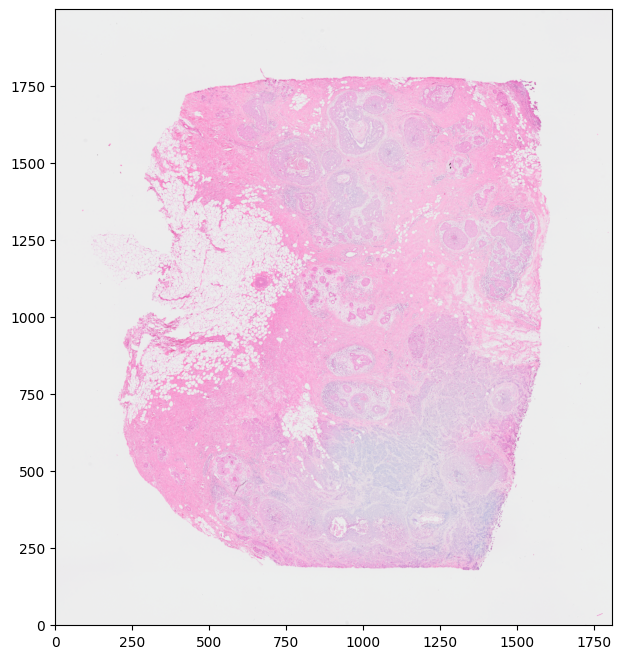

In [4]:
## Quick sanity check that the Visium high resolution H&E image loaded correctly
fig = plt.figure(figsize = (8, 8))
ax = plt.gca()
ax.imshow(visium_high_res_image, origin="lower")


# Part 2: Data Alignment

## Part 2.1: Construct and align Xenium replicate 1 to Visium

Notice that since we are using the Visium high resolution H&E image, the affine transform chain needs to go xenium &rarr; morphology &rarr; visium full res &rarr; visium high res.

In [5]:
rep1_path = {
    "he_img": path_to_visium_bundle / "spatial" / "tissue_hires_image.png",
    "cell_type": path_to_xenium_celltype_labels,
    "cell_info": path_to_xenium_rep1_bundle / "cells.csv.gz",
    "transcript": path_to_xenium_rep1_bundle / "transcripts.parquet",
    "cell_count": path_to_xenium_rep1_bundle / "cell_feature_matrix.h5",
    'morph_img': path_to_xenium_rep1_bundle / "morphology_mip.ome.tif",
}

xenium_to_morphology_transformation = get_xenium_to_morphology_transform_from_xenium_morphology_image(
        path_to_xenium_rep1_bundle / "morphology_mip.ome.tif", 0
    )

xenium_morphology_to_visium_full_res_transformation = np.array(
    [
        [1.87594468e-02, -4.07641677e-01, 1.63476055e04],
        [3.91300071e-01, 1.26819551e-02, 4.12499099e03],
        [-8.39854141e-08, -9.91112632e-07, 1.03706895e00],
    ]
)

visium_full_to_high_scale = np.array(
    [
        [visium_scale_factors["tissue_hires_scalef"], 0, 0],
        [0, visium_scale_factors["tissue_hires_scalef"], 0],
        [0, 0, 1],
    ], dtype = float
)

rep1_affline = visium_full_to_high_scale @ (xenium_morphology_to_visium_full_res_transformation @ xenium_to_morphology_transformation)


[WARNING] xenium: H&E image doesn't have um to pixel conversion.
[INFO] xenium: Total transcript count: 42638083...
[INFO] xenium: After filtering for QC and unassigned cell id, total transcript counts : 32143179...
[INFO] xenium: After filtering for only selected genes, total transcript counts : 31450291...
[INFO] xenium: Locations converted.  Now plotting...


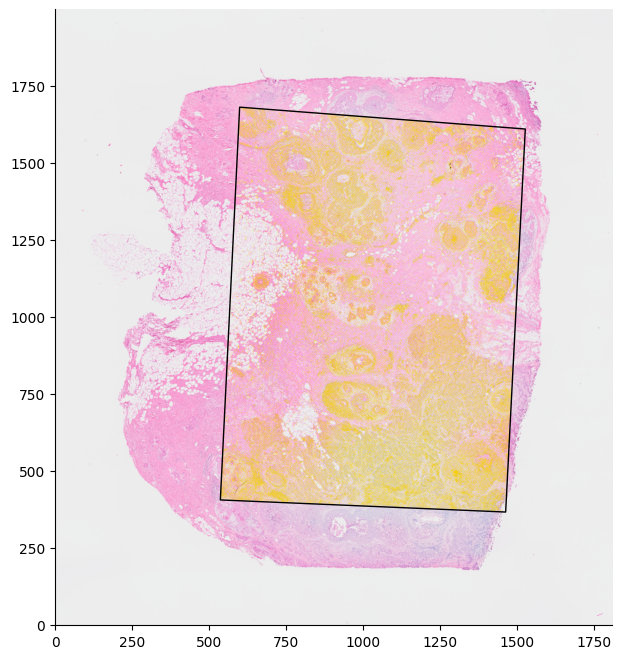

In [6]:
rep1_xenium = xenium_module.Xenium(paths = rep1_path, afline_mat = rep1_affline, selected_genes = visium_adata.var.index.tolist(), cell_type_sheet_name = "Xenium R1 Fig1-5 (supervised)")


## Part 2.2: Construct and align Xenium replicate 2 to Visium

In [7]:
rep2_path = {
    "he_img": path_to_visium_bundle / "spatial" / "tissue_hires_image.png",
    "cell_type": path_to_xenium_celltype_labels,  # replicate 2 shares replicate 1's cell-type labels
    "cell_info": path_to_xenium_rep2_bundle / "cells.csv.gz",
    "transcript": path_to_xenium_rep2_bundle / "transcripts.parquet",
    "cell_count": path_to_xenium_rep2_bundle / "cell_feature_matrix.h5",
    'morph_img': path_to_xenium_rep2_bundle / "morphology_mip.ome.tif",
}

xenium_rep2_to_morphology = get_xenium_to_morphology_transform_from_xenium_morphology_image(
        path_to_xenium_rep2_bundle / "morphology_mip.ome.tif", 0
    )

rep2_morphology_to_rep1_morphology = np.array(
    [
        [1.0048218381499400,	-0.036326146343110600,	-1330.4508310249200],
        [0.036326146343110600,	1.0048218381499400,	8230.273004290340],
        [0,	0,	1],
    ]
)

xenium_morphology_to_visium_full_res_transformation = np.array(
    [
        [1.87594468e-02, -4.07641677e-01, 1.63476055e04],
        [3.91300071e-01, 1.26819551e-02, 4.12499099e03],
        [-8.39854141e-08, -9.91112632e-07, 1.03706895e00],
    ]
)

visium_full_to_high_scale = np.array(
    [
        [visium_scale_factors["tissue_hires_scalef"], 0, 0],
        [0, visium_scale_factors["tissue_hires_scalef"], 0],
        [0, 0, 1],
    ], dtype = float
)

rep2_affline = visium_full_to_high_scale @ xenium_morphology_to_visium_full_res_transformation @ (rep2_morphology_to_rep1_morphology @ xenium_rep2_to_morphology)


[WARNING] xenium: H&E image doesn't have um to pixel conversion.
[INFO] xenium: Total transcript count: 31997227...
[INFO] xenium: After filtering for QC and unassigned cell id, total transcript counts : 23187422...
[INFO] xenium: After filtering for only selected genes, total transcript counts : 22712763...
[INFO] xenium: Locations converted.  Now plotting...


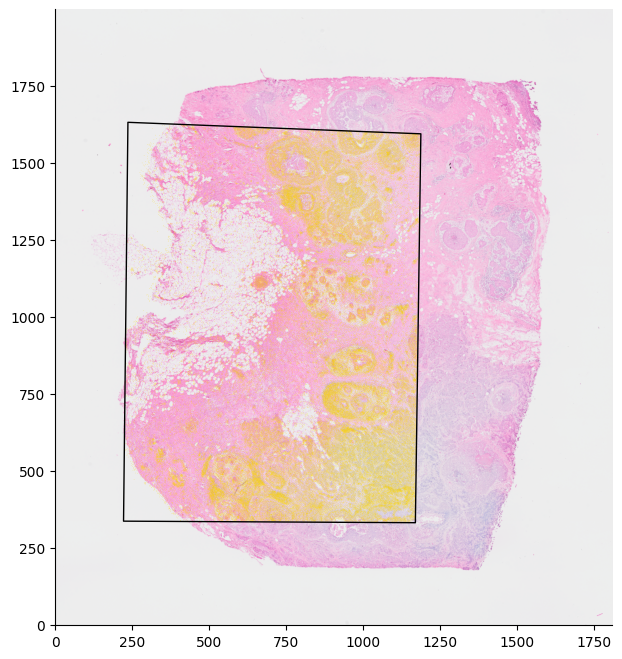

In [8]:
rep2_xenium = xenium_module.Xenium(paths = rep2_path, afline_mat = rep2_affline, selected_genes = visium_adata.var.index.tolist(), cell_type_sheet_name = "Xenium R1 Fig1-5 (supervised)")


## Part 2.3: Generate spot polygons from real Visium coordinates

We already have a set of real coordinates for Visium, so let's build each replicate's spot
polygons directly from the given Visium spot coordinates (rather than assuming a margin/spacing,
as is needed when no real Visium data is available).

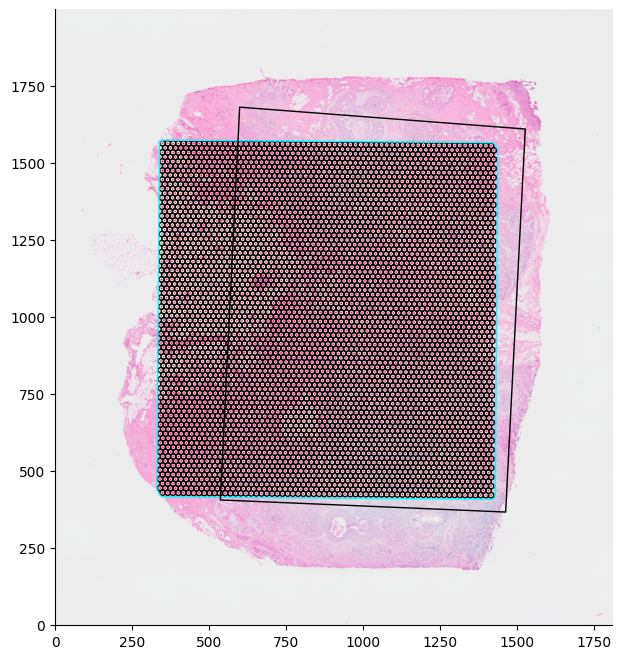

In [9]:
## collect the real visium coordinates and diameter.  Convert into high res resolution
spot_coords = visium_tissue_positions[
        ["pxl_col_in_fullres", "pxl_row_in_fullres"]
    ].values * visium_scale_factors["tissue_hires_scalef"]
diameter = visium_scale_factors["spot_diameter_fullres"] * visium_scale_factors["tissue_hires_scalef"]

rep1_xenium.polygons_from_coords(spot_coords, diameter, visium_tissue_positions.index.tolist())


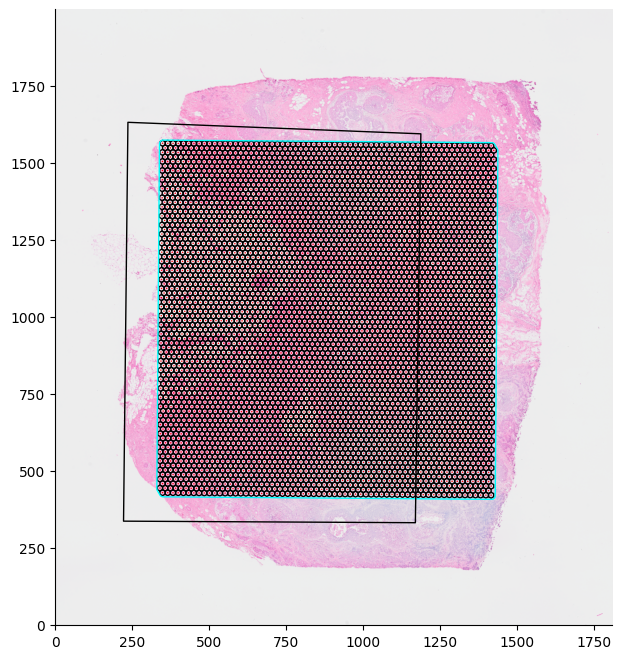

In [10]:
rep2_xenium.polygons_from_coords(spot_coords, diameter, visium_tissue_positions.index.tolist())


## Part 2.4: Visualize overlap of Visium, Xenium replicate 1, and Xenium replicate 2 capture areas

This figure highlights, with a red box, where the Visium capture area and both Xenium replicates'
capture areas overlap. The overlap is computed as the intersection of the three capture polygons'
axis-aligned bounding boxes (an approximation, not the exact polygon intersection).


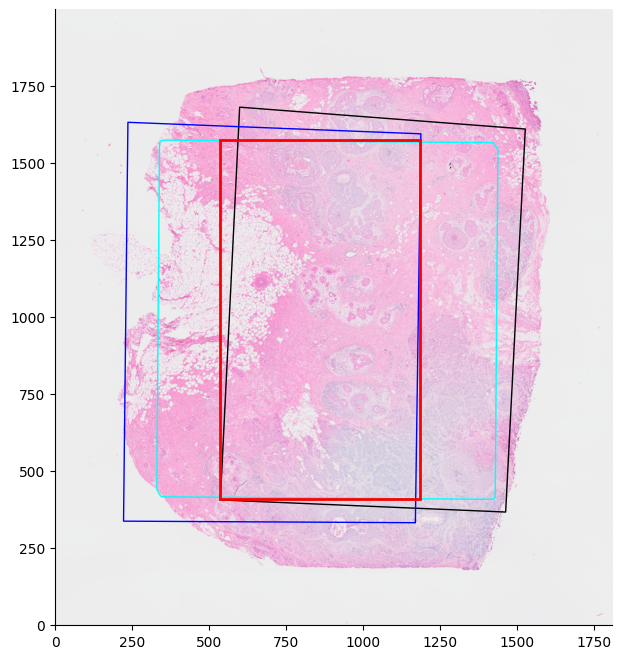

In [11]:
def bbox(poly):
    poly = np.asarray(poly)
    return poly[:, 0].min(), poly[:, 0].max(), poly[:, 1].min(), poly[:, 1].max()

visium_bbox = bbox(rep1_xenium.generated_capture_polygon)
rep1_bbox = bbox(rep1_xenium.xenium_capture_polygon)
rep2_bbox = bbox(rep2_xenium.xenium_capture_polygon)

overlap_x_min = max(visium_bbox[0], rep1_bbox[0], rep2_bbox[0])
overlap_x_max = min(visium_bbox[1], rep1_bbox[1], rep2_bbox[1])
overlap_y_min = max(visium_bbox[2], rep1_bbox[2], rep2_bbox[2])
overlap_y_max = min(visium_bbox[3], rep1_bbox[3], rep2_bbox[3])

assert overlap_x_min < overlap_x_max and overlap_y_min < overlap_y_max, (
    "Visium, replicate 1, and replicate 2 capture areas do not overlap."
)

fig = plt.figure(figsize=(8, 8))
ax = plt.gca()
ax.imshow(visium_high_res_image, origin="lower")

## individual capture areas, for context
plot_polygons([rep1_xenium.generated_capture_polygon], ax=ax,
              facecolor=(0, 0, 0, 0), edgecolor="cyan", linewidth=1)
plot_polygons([rep1_xenium.xenium_capture_polygon], ax=ax,
              facecolor=(0, 0, 0, 0), edgecolor="black", linewidth=1)
plot_polygons([rep2_xenium.xenium_capture_polygon], ax=ax,
              facecolor=(0, 0, 0, 0), edgecolor="blue", linewidth=1)

## overlap of all three, highlighted in red
ax.add_patch(Rectangle(
    (overlap_x_min, overlap_y_min),
    overlap_x_max - overlap_x_min,
    overlap_y_max - overlap_y_min,
    facecolor=(0, 0, 0, 0),
    edgecolor="red",
    linewidth=2,
))

ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.yaxis.set_ticks_position("left")
ax.xaxis.set_ticks_position("bottom")
ax.set_aspect("equal", adjustable="box")


# Part 3: Simulating Pseudo Spots

Pseudo spots are generated by assigning each transcript to the nearest spot center within a
fixed radius (`generate_pseudo_spot`), modeling a spot's physical capture disc, rather than by
assigning every transcript to its nearest spot regardless of distance.


## Part 3.1: Generate pseudo spots for replicate 1

In [12]:
rep1_xenium.generate_pseudo_spot(radius = visium_scale_factors["spot_diameter_fullres"]/2 * visium_scale_factors["tissue_hires_scalef"])


Processing transcripts: 100%|██████████| 315/315 [00:17<00:00, 18.39batch/s]
[INFO] xenium: Total transcript 31450291, in capture transcript 27590836,in visium disc transcript 11921120


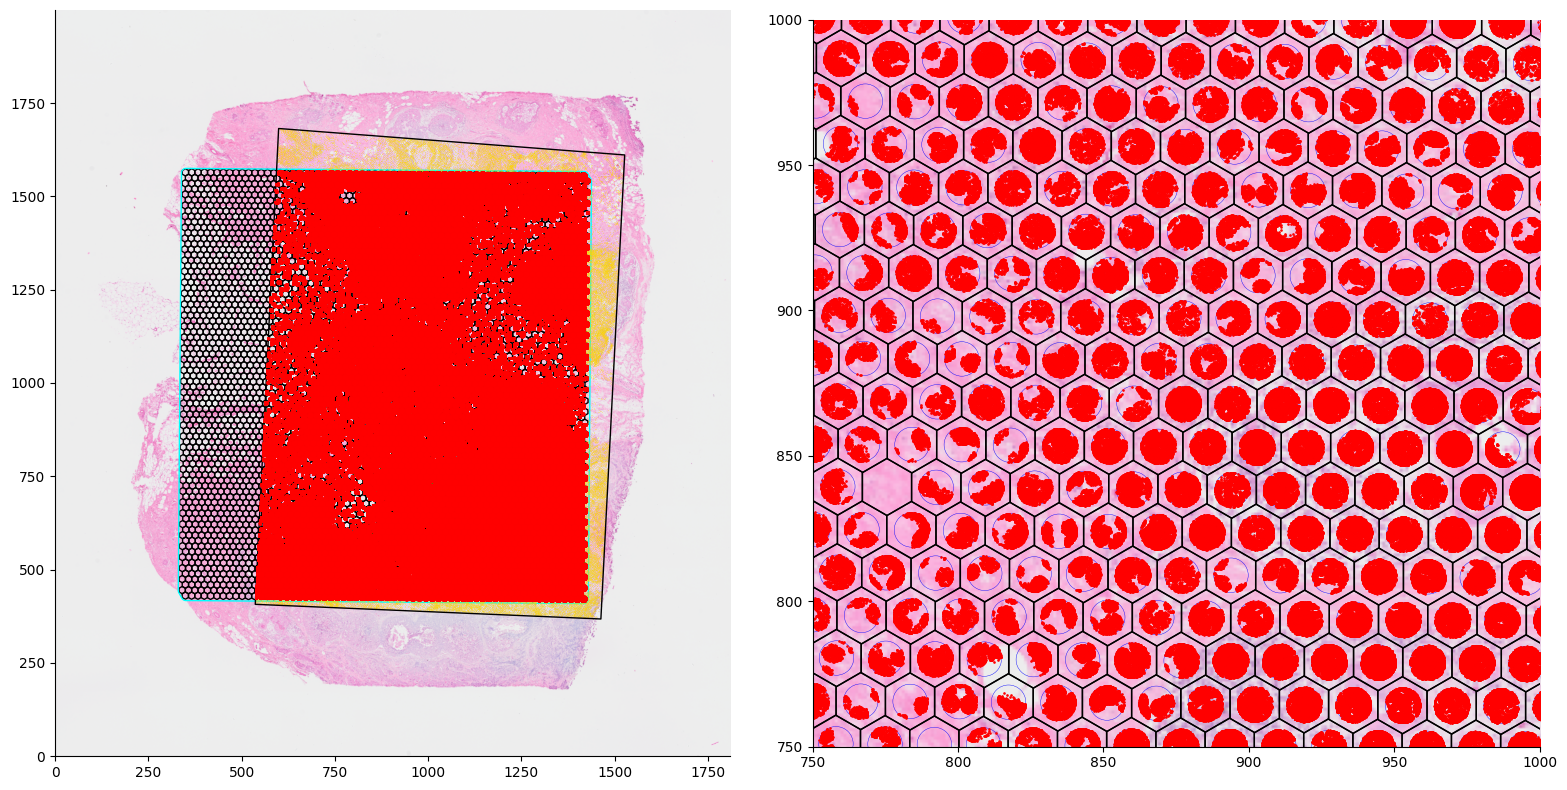

In [13]:
rep1_xenium.pseudo_visualize()


## Part 3.2: Generate pseudo spots for replicate 2

In [14]:
rep2_xenium.generate_pseudo_spot(radius = visium_scale_factors["spot_diameter_fullres"]/2 * visium_scale_factors["tissue_hires_scalef"])


Processing transcripts: 100%|██████████| 228/228 [00:12<00:00, 18.75batch/s]
[INFO] xenium: Total transcript 22712763, in capture transcript 19336118,in visium disc transcript 8383617


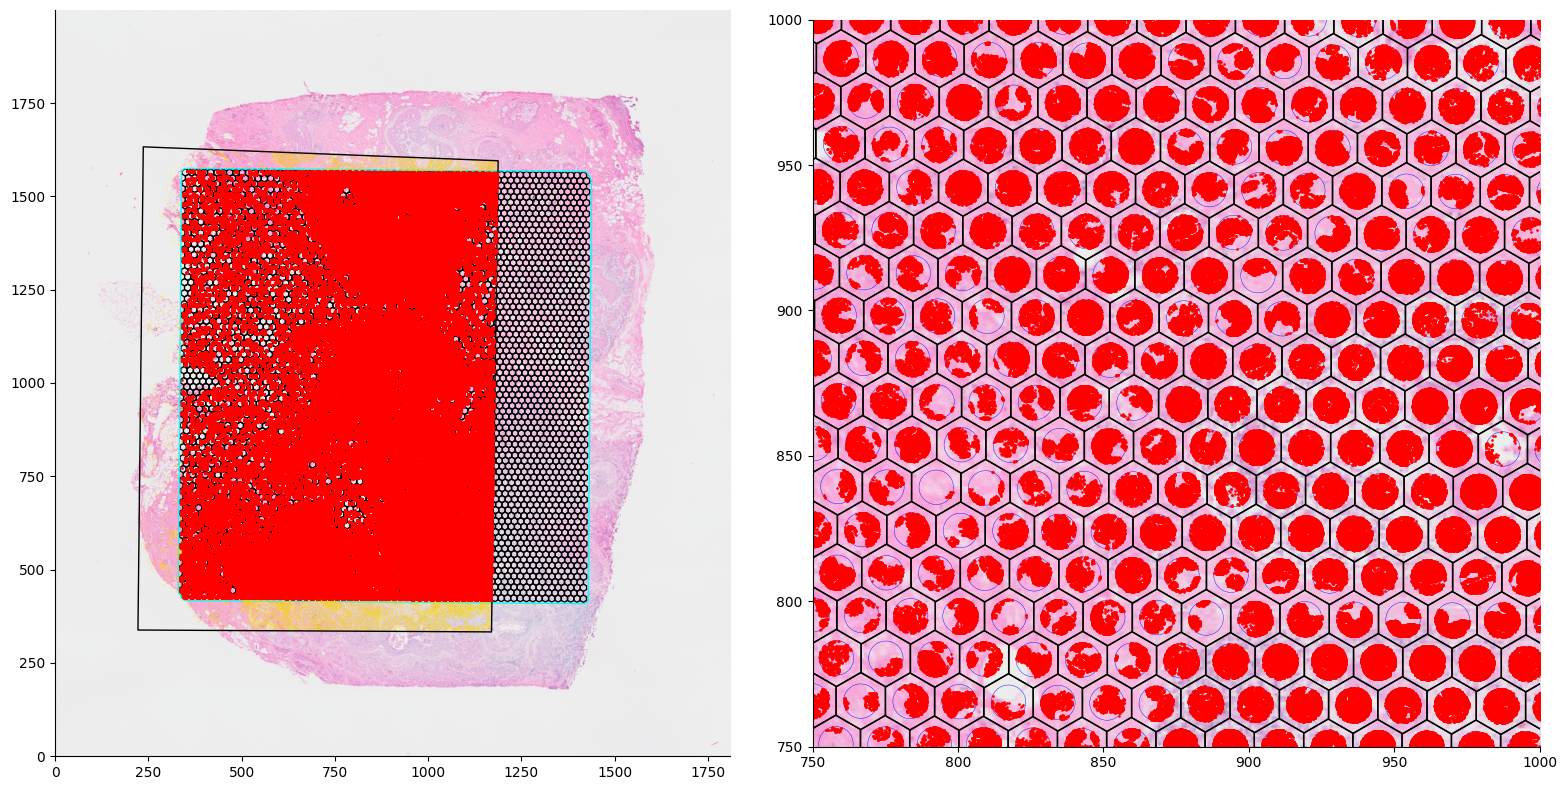

In [15]:
rep2_xenium.pseudo_visualize()


## Part 3.3: Restrict to spots shared by Visium, replicate 1, and replicate 2, and save

In [16]:
overlap_barcode = rep1_xenium.pseudo_count.index.intersection(rep2_xenium.pseudo_count.index)
print(f"Rep 1 and rep 2 and visium have {len(overlap_barcode)} common spots...")


Rep 1 and rep 2 and visium have 2801 common spots...


In [17]:
rep1_xenium.save_data(path = "../../../data/realistic_preprocessed/validation", sel_spots = np.asarray(overlap_barcode))


[INFO] xenium: Selected 2801 out of 3943 spots...
[INFO] xenium: selected total 61419 cells...
[INFO] xenium: Finished writing cell spot proportion...
[INFO] xenium: Finished writing cell-gene dropout fraction...
[INFO] xenium: Finished saving training cell meta and count information...
[INFO] xenium: Finished saving pseudo meta and count information


Replicate 2's pseudo-spot export below is restricted to `overlap_barcode` (Visium &cap; replicate 1
&cap; replicate 2), matching replicate 1's `sel_spots` restriction above so both replicates share
the same spot set. Replicate 2 uses a lighter export (`pseudo_count`/`pseudo_meta` only) rather
than the full transcript/cell-level `save_data()` pipeline used for replicate 1.


In [19]:
path = Path("../../../data/realistic_preprocessed/validation")
path.mkdir(parents=True, exist_ok=True)

rep1_xenium.pseudo_count.loc[overlap_barcode].to_csv(path / "pseudo_count.csv")

rep2_xenium.pseudo_count.loc[overlap_barcode].to_csv(path / "pseudo_count_rep2B.csv")
rep2_xenium.pseudo_meta.loc[overlap_barcode].to_csv(path / "pseudo_meta_rep2B.csv")


# Part 4: Save Visium

Now we are at the last step of saving Visium data.

In [20]:
visium_adata.X.shape


(4992, 18085)

In [21]:
genes_xenium = rep1_xenium.pseudo_count.columns.tolist()
genes_xenium = [x.decode('utf-8') if isinstance(x, bytes) else x for x in genes_xenium]
visium_count = pd.DataFrame.sparse.from_spmatrix(visium_adata.X, index = visium_adata.obs.index, columns = visium_adata.var.index)
visium_count[genes_xenium].to_csv(path / "visium_count.csv")
visium_meta = pd.DataFrame(spot_coords, index = visium_adata.obs.index, columns =["x", "y"])
visium_meta.to_csv(path / "visium_meta.csv")
